# Hierarchical inference of the mass & concentration population

This notebook walks through a full **hierarchical Bayesian** workflow for galaxy-cluster weak-lensing profiles. The goal is to recover the *population* distributions of halo mass and concentration — not just the value for any single cluster.

**The road map below:**

1. **Build a mock universe.** Draw a population of clusters whose true (log-)masses and concentrations come from Gaussian population distributions with known $(\mu, \tau)$.
2. **Forward-model each cluster.** Use an NFW profile to turn each cluster's $(\log_{10}M, c)$ into a surface-density profile, then add observational noise.
3. **Fit every cluster individually.** Run MCMC per cluster to get a posterior chain on $(\log_{10}M, c)$ — this mimics the output of a real weak-lensing pipeline.
4. **Recycle those chains into a hyper-model.** Infer the population-level $(\mu, \tau)$ by marginalizing over the per-cluster posteriors (importance-sampling / "recycling" trick).
5. **Compare against naive baselines** (naive pooling, OLS of posterior means) and visualize how well each recovers the *true* population.

We start with the imports: `numpy`/`matplotlib` for the math and plots, and `pymc`/`pytensor` for the probabilistic modeling.

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt

## Step 1 — Define the *true* population

Here we set up the ground truth for our mock universe. We generate `n_clusters_pc = 100` clusters and draw:

- **`m`** — the true $\log_{10}$ masses, scattered around $14.3$ with a small spread.
- **`cc`** — the true concentrations, scattered around $5.0$.

From these we compute the true population means and spreads (`mu_m_true`, `tau_m_true`, `mu_cc_true`, `tau_cc_true`). **These are the numbers our hierarchical model must recover at the end** — keep them in mind as the "answer key."

`noise_dex_pc` is the per-radial-bin measurement noise (in dex) we will later inject into the profiles.

> The triple-quoted block is a preview of the *recycling* likelihood we build in Step 4 — it is inert here (just a string) and is shown early so you can see where we are heading.

In [114]:
n_clusters_pc = 100
m = 14.3 + 0.10*np.random.randn(n_clusters_pc)


mu_m_true=np.mean(m)
tau_m_true=np.std(m)

"""
mass_samples_pt = pt.as_tensor_variable(mass_samples)

pop_density = pt.exp(
    -0.5*((mass_samples_pt-mu)/tau)**2
)/tau

mc_integral = pt.mean(pop_density, axis=1)

pm.Potential("lp", pt.sum(pt.log(mc_integral + 1e-300)) + lt)
"""
cc = 5.0 + 0.7*np.random.randn(n_clusters_pc)

mu_cc_true=np.mean(cc)
tau_cc_true=np.std(cc)

noise_dex_pc = 0.10



## Step 2 — The NFW forward model

Next we build the physics that maps a cluster's parameters $(\log_{10}M, c)$ onto an observable **surface-density profile**. We use [`colossus`](https://bdiemer.bitbucket.io/colossus/) for the cosmology and NFW halo definitions, evaluated on a fixed radial grid `nfw_r`.

The `NFWProfile` class below is written **twice on purpose**:

- **`*_np` methods** (`mu_np`, `f_function_np`, `log_surfaceDensity_np`) — plain NumPy. Handy for generating the mock data and for sanity checks.
- **`pytensor` methods** (`mu`, `f_function`, `log_surfaceDensity`) — symbolic versions that PyMC can differentiate and trace through during sampling. Note how `pt.switch` replaces the Python `if/elif/else` in `f_function`, since a tensor's value isn't known at graph-build time.

`nfw_logSigma(theta)` is a thin NumPy wrapper we'll use to synthesize noisy observations. **Next**, we draw per-cluster true parameters and feed them through this model.

In [115]:
from colossus.cosmology import cosmology 
from colossus.halo import profile_nfw
from colossus.halo import mass_so
cosmology.setCosmology("planck18") 
nfw_r = 10**np.arange(0, 2.0, 0.1)
def nfw_logSigma(theta):                         # theta = (log10 mass, concentration)
        h = profile_nfw.NFWProfile(M=10**theta[0], c=theta[1], z=0.0, mdef="vir")
        return np.log10(h.surfaceDensity(nfw_r))
class NFWProfile:
    def __init__(self, M, c, z=0.0, mdef="vir"):
        self.M = M
        self.c = c
        self.z = z
        self.mdef = mdef
        self.rhos,self.rs = self.nativeParameters_tensor(M=self.M, c=self.c)
    
    def mu(self, x):
        return pt.log(1 + x) - x/(1 + x)

    def nativeParameters_tensor(self, M, c):
        rho0 = mass_so.densityThreshold(0.0, "vir")
        R = (3 * M / (4 * np.pi * rho0)) ** (1.0/3.0)
        rs = R / c
        rhos = M / (4 * np.pi * rs**3 * self.mu(c))
        return rhos, rs
    def mu_np(self, x):
            return np.log(1 + x) - x/(1 + x)
    def nativeParameters_tensor_np(self, M, c):
            rho0 = mass_so.densityThreshold(0.0, "vir")
            R = (3 * M / (4 * np.pi * rho0)) ** (1.0/3.0)
            rs = R / c
            rhos = M / (4 * np.pi * rs**3 * self.mu_np(c))
            return rhos, rs
    
    
    def print_type(self):
        print(type(self.rhos), type(self.rs))

    
    def density(self, R):
        # Placeholder for actual NFW density calculation
        return self.rhos / ((R / self.rs) * (1 + R / self.rs)**2)
    
    #for P:
    def f_function_np(self, x):
        if x<1:
            return (1/(x**2-1))*(1-(2/np.sqrt(1-x**2))*np.arctanh(np.sqrt((1-x)/(1+x))))
        elif x==1:
            return 1/3
        else:
            return (1/(x**2-1))*(1-(2/np.sqrt(x**2-1))*np.arctan(np.sqrt((x-1)/(1+x))))
    def log_surfaceDensity_np(self, R):
        # Placeholder for actual surface density calculation
        self.rhos, self.rs = self.nativeParameters_tensor_np(M=self.M, c=self.c)
        integrand = np.zeros((len(R)), dtype=float)
        for j in range(len(R)):
            if R[j] <= 0:
                raise ValueError("R must be positive")
            integrand[j] = 2*self.rhos*self.rs*self.f_function_np(R[j]/self.rs)
        return np.log10(integrand)  # Return log10 of the integral values
    
    
    #with the tensor
    def f_function(self, x):
        f_lt = (1/(x**2-1))*(1-(2/pt.sqrt(1-x**2))*pt.arctanh(pt.sqrt((1-x)/(1+x))))
        f_eq = 1.0/3.0
        f_gt = (1/(x**2-1))*(1-(2/pt.sqrt(x**2-1))*pt.arctan(pt.sqrt((x-1)/(1+x))))

        f = pt.switch(
            pt.lt(x, 1),
            f_lt,
            pt.switch(
                pt.gt(x, 1),
                f_gt,
                f_eq
            )
        )
        return f
        #return np.log10(integrand)  # Return log10 of the integral values
    def log_surfaceDensity(self, R):
        x = pt.as_tensor_variable(R) / self.rs
        answer=2*self.rhos*self.rs*self.f_function(x)
        return pt.log10(answer)  # Return log10 of the integral values

## Step 3a — Draw each cluster's true parameters

We now draw the individual "truths" for each of the 100 clusters straight from the true population Gaussians: `theta_true_pc_m` (masses) and `theta_true_pc_c` (concentrations). These per-cluster values are the histogram we will later overplot against our inferred population curve — they represent the actual spread of clusters in this mock universe.

In [116]:
theta_true_pc_c = mu_cc_true + tau_cc_true * np.random.randn(n_clusters_pc)
theta_true_pc_m = mu_m_true + tau_m_true * np.random.randn(n_clusters_pc)

## Step 3b — Inspect the radial grid

A quick sanity check: print the radial bins `nfw_r` (log-spaced from $1$ to $\sim100$) at which every profile is evaluated. Each mock observation will be a vector of surface densities of this length.

In [117]:
print(nfw_r)

[ 1.          1.25892541  1.58489319  1.99526231  2.51188643  3.16227766
  3.98107171  5.01187234  6.30957344  7.94328235 10.         12.58925412
 15.84893192 19.95262315 25.11886432 31.6227766  39.81071706 50.11872336
 63.09573445 79.43282347]


## Step 3c — Synthesize data and fit each cluster individually

This is the heavy-lifting cell. Two things happen:

1. **Mock observations** — `profiles_pc` is built by pushing each cluster's true $(m, cc)$ through `nfw_logSigma` and adding Gaussian noise (`noise_dex_pc`). This is our stand-in for real weak-lensing measurements.

2. **Per-cluster inference** — we build one PyMC `model` with uniform priors on `log10M` and `c`, an NFW-predicted mean profile, and a Normal likelihood. Then we loop over all 100 clusters, swapping in each cluster's data with `model.set_data("obs", ...)` and running the NUTS sampler.

The output `cluster_samples` has shape `(n_clusters_pc, S, 2)` — **a posterior chain on (mass, concentration) for every cluster.** This is exactly the deliverable a real WL pipeline produces per object, and it becomes the *input* to the hierarchical stage.

> ⏳ This cell runs a full MCMC fit 100 times, so expect it to take a while. `progressbar=False` keeps the output clean; the per-cluster `print(j)` gives a coarse progress signal.

In [118]:
profiles_pc = np.array([
    nfw_logSigma([m[j], cc[j]]) +
    noise_dex_pc*np.random.randn(len(nfw_r))
    for j in range(n_clusters_pc)
])
with pm.Model() as model:
    # same priors as your log_prior()
    obs = pm.Data("obs", profiles_pc[0])
    log10M = pm.Uniform("log10M", 13.5, 15)
    c = pm.Uniform("c", 1, 12)
    # profile_model(theta)
    mu = NFWProfile(M=10**log10M, c=c).log_surfaceDensity(nfw_r)
    # likelihood
    pm.Normal(
        "likelihood",
        mu=mu,
        sigma=noise_dex_pc,
        observed=obs
    )
cluster_samples = [] 
                                    # list of (n_walkers*n_steps, 2) arrays, one per cluster
print(f"Fitting {n_clusters_pc} clusters individually (per-bin noise = {noise_dex_pc} dex)...")
for j in range(n_clusters_pc):
    model.set_data("obs", profiles_pc[j])
    with model:
        trace = pm.sample(
            draws=700,
            tune=500,
            chains=4,
            target_accept=0.9,
            progressbar=False
        )
    s = np.column_stack([
        trace.posterior["log10M"].values.reshape(-1),
        trace.posterior["c"].values.reshape(-1),
    ])
    cluster_samples.append(s)
    print(j)
cluster_samples = np.array(cluster_samples)         # shape: (n_clusters_pc, S, 2)
print("cluster_samples shape =", cluster_samples.shape, " (clusters, posterior samples, params)")
print("   <- this is what a WL pipeline gives you per cluster: a chain on (mass, concentration)")

Fitting 100 clusters individually (per-bin noise = 0.1 dex)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log10M, c]
Sampling 4 chains for 500 tune and 700 draw iterations (2_000 + 2_800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...


0


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log10M, c]
Sampling 4 chains for 500 tune and 700 draw iterations (2_000 + 2_800 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...


1


...

97


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log10M, c]
Sampling 4 chains for 500 tune and 700 draw iterations (2_000 + 2_800 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...


98


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log10M, c]
Sampling 4 chains for 500 tune and 700 draw iterations (2_000 + 2_800 draws total) took 1 seconds.


99
cluster_samples shape = (100, 2800, 2)  (clusters, posterior samples, params)
   <- this is what a WL pipeline gives you per cluster: a chain on (mass, concentration)


## Step 3D - Saving the Cluster Samples
Now that we have our cluster samples from the MCMC chain, we can save these as arrays for the mass and concentration respectively. This way all we have to do is reweight them when we need to use them rather than having to rerun the chain everytime!

In [139]:
np.savetxt('mass_cluster_samples.csv', cluster_samples[:, :, 0])
np.savetxt('concentration_cluster_samples.csv', cluster_samples[:, :, 1])

## Step 4 — The hyper-model: recovering the mass population

Now the hierarchical payoff. We split `cluster_samples` into `m_samples` and `c_samples` (each `n_clusters × S`) and infer the **population** parameters $(\mu, \tau)$ that generated the per-cluster truths.

The key idea is **"recycling"** the existing per-cluster chains instead of re-fitting the profiles. For a trial population $N(\mu, \tau)$, the marginal likelihood of cluster $j$ is approximated by averaging the population density over that cluster's posterior draws:

$$ p(\text{data}_j \mid \mu, \tau) \approx \frac{1}{S}\sum_s N\!\left(\theta_{j,s} \mid \mu, \tau\right) $$

That Monte-Carlo average is exactly `mc_integral = pt.mean(pop_density, axis=1)`, and we add its log to the model via `pm.Potential`. We sample $\tau$ in log-space (`lt`) for positivity, with a flat prior on $\mu$; the extra `+ lt` is the Jacobian of that transform.

This cell handles **mass** and stores the hyper-posterior in `mu_hat_m`, `tau_hat_m`. **Next** we repeat the identical recipe for concentration.

> We use `pm.Metropolis()` here because the potential is a custom expression; NUTS would need gradients through the recycling sum.

In [131]:
m_samples = cluster_samples[:, :, 0]   # (100, 8000)
c_samples = cluster_samples[:, :, 1]   # (100, 8000)

with pm.Model() as hyper_model_m:

    mu = pm.Flat("mu")
    lt = pm.Uniform("lt", -10, np.log(3))

    tau = pt.exp(lt)

    total = 0

    m_samples_pt = pt.as_tensor_variable(m_samples)

    pop_density = pt.exp(
        -0.5 * ((m_samples_pt - mu) / tau) ** 2
    ) / tau
    #with a non flat prior will have to divide this by the prior density to get the correct likelihood contribution
    mc_integral = pt.mean(pop_density, axis=1)

    total = pt.sum(pt.log(mc_integral + 1e-300))

    pm.Potential("lp", total + lt)


    hyper_trace = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        step=pm.Metropolis(),
        progressbar=False,
    )
mu_hat_m = hyper_trace.posterior["mu"].values.reshape(-1)
tau_hat_m = np.exp(
    hyper_trace.posterior["lt"].values.reshape(-1)
)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [lt]
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 33 seconds.


## Step 4 (cont.) — The same hyper-model for concentration

Identical machinery as the mass cell, but fed `c_samples`. The result is the concentration hyper-posterior `mu_hat_c`, `tau_hat_c`.

> In a fully joint treatment you would model mass and concentration together with a 2-D population (allowing correlation between them). Here we treat them independently for clarity — a natural **extension** once the 1-D case is understood.

In [ ]:
with pm.Model() as hyper_model_c:

    mu = pm.Flat("mu")
    lt = pm.Uniform("lt", -10, np.log(3))

    tau = pt.exp(lt)

    total = 0

    c_samples_pt = pt.as_tensor_variable(c_samples)

    pop_density = pt.exp(
        -0.5 * ((c_samples_pt - mu) / tau) ** 2
    ) / tau
    #with a non flat prior will have to divide this by the prior density to get the correct likelihood contribution
    mc_integral = pt.mean(pop_density, axis=1)

    total = pt.sum(pt.log(mc_integral + 1e-300))

    pm.Potential("lp", total + lt)


    hyper_trace = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        step=pm.Metropolis(),
        progressbar=False,
    )
mu_hat_c = hyper_trace.posterior["mu"].values.reshape(-1)
tau_hat_c = np.exp(
    hyper_trace.posterior["lt"].values.reshape(-1)
)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [lt]
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 35 seconds.


## Step 5a — Peek at the hyper-posterior draws

A quick check that the concentration hyper-chain looks reasonable: print `mu_hat_c` and its length. Each entry is one posterior sample of the population mean $\mu_c$ — the collection of them is what we'll draw the "spaghetti" of candidate population curves from in the plots below.

In [121]:
print(mu_hat_c)
print(len(mu_hat_c))

[4.94461367 4.56122583 4.56122583 ... 4.98695648 4.96566456 4.88559819]
8000


## Step 5b — Baseline estimators to compare against

Before plotting, we compute two simpler (and biased) ways one *might* estimate the population, so the hierarchical result has something to beat:

- **Naive pool** (`mu_pool`, `tau_pool`) — throw every posterior draw from every cluster into one big bag and take its mean/std. This **over-counts measurement scatter**, inflating $\tau$.
- **OLS centers** (`mu_ols`, `tau_ols`) — collapse each cluster to its posterior-mean point estimate, then take the mean/std of those 100 points. This ignores per-cluster uncertainty and tends to **misestimate the spread**.

We compute both for mass and concentration. **Next**, the plots overlay all of these against the true population.

In [122]:
pooled_m = cluster_samples[:, :, 0].ravel()
mu_pool_m   = pooled_m.mean()
tau_pool_m  = pooled_m.std()
pooled_c = cluster_samples[:, :, 1].ravel()
mu_pool_c   = pooled_c.mean()
tau_pool_c  = pooled_c.std()

m_hat = cluster_samples[:, :, 0].mean(axis=1)    # one number per cluster: the posterior mean of a_j
mu_ols_m  = m_hat.mean()
tau_ols_m = m_hat.std()
c_hat = cluster_samples[:, :, 1].mean(axis=1)    # one number per cluster: the posterior mean of a_j
mu_ols_c  = c_hat.mean()
tau_ols_c = c_hat.std()

In [123]:
print(len(mu_hat_m))

8000


## Step 6 — Visualize the mass population recovery

The final two cells produce the money plots. For **mass** first:

- **Grey histogram** — the true per-cluster masses `theta_true_pc_m` (the real spread).
- **Black solid** — the true population Gaussian $N(\mu_{\text{true}}, \tau_{\text{true}})$.
- **Purple spaghetti** — 80 draws from the hyper-posterior, each a plausible population curve; their spread *is* our uncertainty on the population.
- **Purple dashed** — the mean recycled (hierarchical) estimate.
- **Red / orange** — the naive-pool and OLS baselines for contrast.

The figure is saved to `mass_population_distribution.pdf`.

**What to look for:** the purple dashed curve should hug the black one, while red (too wide) and orange visibly miss — the payoff of doing the inference hierarchically.

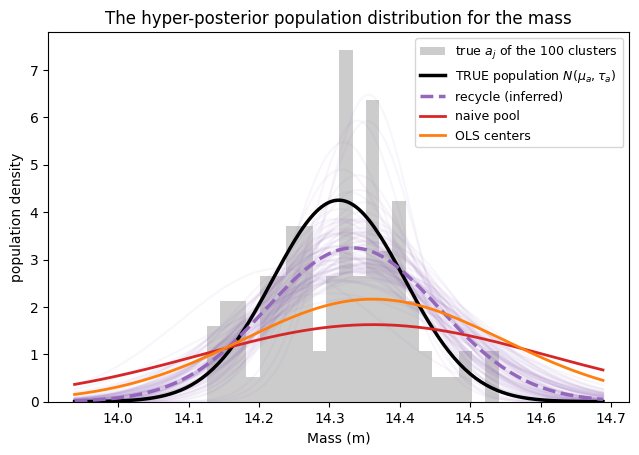

In [125]:
# Does the inferred population distribution match the actual cluster spread?
xx = np.linspace(mu_m_true - 4*tau_m_true, mu_m_true + 4*tau_m_true, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
plt.figure(figsize=(7.5, 4.8))
plt.hist(theta_true_pc_m, bins=22, density=True, color="0.8", label="true $a_j$ of the %d clusters" % n_clusters_pc)
idx = np.random.randint(len(mu_hat_m), size=80)
for mh, th in zip(mu_hat_m[idx], tau_hat_m[idx]):                              # spaghetti from hyper-posterior
    plt.plot(xx, gauss(xx, mh, th), color="tab:purple", alpha=0.06)
plt.plot(xx, gauss(xx, mu_m_true,    tau_m_true),    "k-",  lw=2.5, label=r"TRUE population $N(\mu_a,\tau_a)$")
plt.plot(xx, gauss(xx, mu_hat_m.mean(), tau_hat_m.mean()), "--", color="tab:purple", lw=2.5, label="recycle (inferred)")
plt.plot(xx, gauss(xx, mu_pool_m,       tau_pool_m),    "-",  color="tab:red",    lw=2.0, label="naive pool")
plt.plot(xx, gauss(xx, mu_ols_m,        tau_ols_m),     "-",  color="tab:orange", lw=2.0, label="OLS centers")
plt.xlabel("Mass (m)") 
plt.ylabel("population density")
plt.title("The hyper-posterior population distribution for the mass") 
plt.legend(fontsize=9)
plt.savefig("mass_population_distribution.pdf", dpi=300)
plt.show()

### A note on the spurious tall spaghetti peaks

A handful of spaghetti draws come out with a peak *far* taller than the dashed mean curve. That is **not** a plotting glitch — it is the well-known **variance-collapse singularity** of the recycling estimator. A Gaussian's peak height is $\tfrac{1}{\tau\sqrt{2\pi}}$, so a draw with tiny $\tau$ spikes arbitrarily high, and those tiny-$\tau$ draws are genuine hyper-posterior samples because the marginal likelihood

$$\prod_j\Big(\tfrac{1}{S}\textstyle\sum_s N(\theta_{j,s}\mid\mu,\tau)\Big)$$

is **unbounded as $\tau\to 0$**: when $\mu$ sits near a cluster's draws, the $\exp$ term stays $\approx 1$ while the $1/\tau$ prefactor blows up (the same degeneracy that makes a Gaussian mixture diverge when one component collapses onto a data point). Since `lt` is `Uniform(-10, log 3)`, $\tau$ can reach $e^{-10}\approx 5\times10^{-5}$, and the Metropolis chain occasionally visits that spike.

A principled fix is to **penalize small $\tau$ in the prior** — e.g. raise the lower `lt` bound, or replace the flat log-uniform with a half-Cauchy/half-normal on $\tau$ — so the sampler never parks on the singularity in the first place.

## Step 6 (cont.) — And the concentration population

The same plot for **concentration**, using `mu_hat_c` / `tau_hat_c` and the concentration baselines, saved to `concentration_population_distribution.pdf`.

### Where to go next

- **Joint 2-D population.** Model $(\log_{10}M, c)$ together with a full covariance to capture the mass–concentration relation instead of two independent 1-D fits.
- **Non-Gaussian populations.** Swap the Gaussian hyper-prior for a skewed or mixture distribution if the true population is not symmetric.
- **Sampler upgrade.** Reformulate the recycling potential so it's differentiable and switch from `Metropolis` to `NUTS` for better mixing.
- **Robustness checks.** Vary `noise_dex_pc`, `n_clusters_pc`, and the number of per-cluster draws `S` to see how each affects recovery of $(\mu, \tau)$.

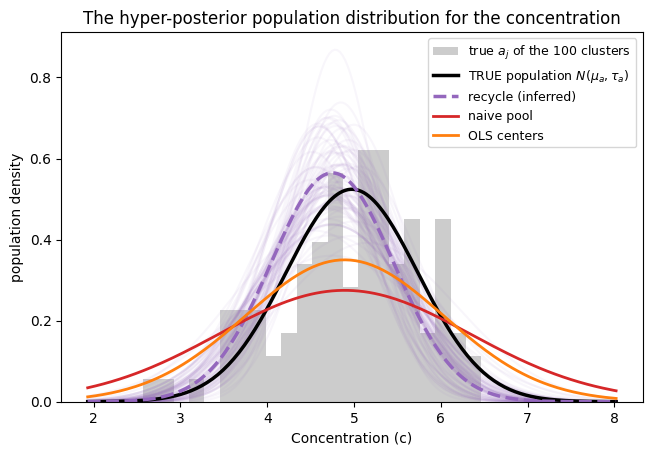

In [126]:
xx = np.linspace(mu_cc_true - 4*tau_cc_true, mu_cc_true + 4*tau_cc_true, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
plt.figure(figsize=(7.5, 4.8))
plt.hist(theta_true_pc_c, bins=22, density=True, color="0.8", label="true $a_j$ of the %d clusters" % n_clusters_pc)
idx = np.random.randint(len(mu_hat_c), size=80)
for mh, th in zip(mu_hat_c[idx], tau_hat_c[idx]):                              # spaghetti from hyper-posterior
    plt.plot(xx, gauss(xx, mh, th), color="tab:purple", alpha=0.06)
plt.plot(xx, gauss(xx, mu_cc_true,    tau_cc_true),    "k-",  lw=2.5, label=r"TRUE population $N(\mu_a,\tau_a)$")
plt.plot(xx, gauss(xx, mu_hat_c.mean(), tau_hat_c.mean()), "--", color="tab:purple", lw=2.5, label="recycle (inferred)")
plt.plot(xx, gauss(xx, mu_pool_c,       tau_pool_c),    "-",  color="tab:red",    lw=2.0, label="naive pool")
plt.plot(xx, gauss(xx, mu_ols_c,        tau_ols_c),     "-",  color="tab:orange", lw=2.0, label="OLS centers")
plt.xlabel("Concentration (c)")
plt.ylabel("population density")
plt.title("The hyper-posterior population distribution for the concentration")
plt.legend(fontsize=9)
plt.savefig("concentration_population_distribution.pdf", dpi=300)
plt.show()